# Isotropic coordinate system transformations

RBFs are *isotropic* — they depend only on $\|x - c\|$, so the model assumes the response varies at the same rate in every direction. Real responses rarely do, and that mismatch is model bias; it is why adding gradients can fail to help.

The fix is pre-processing: estimate a rotation and per-direction scaling that make the data roughly isotropic, then fit there.

The test problem is decomposable, so its ideal frame is known exactly; rotating it couples the variables, forcing a scheme to recover both rotation and scaling.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import qmc

from ge_rbf import IsotropicTransformer, RBFRegressor, gradient_search
from ge_rbf.problems import non_isotropic, random_rotation

rotation = random_rotation(2, rng=5)

X = qmc.LatinHypercube(d=2, seed=1).random(15)
y, dy = non_isotropic(X, rotation)

print(f"{X.shape[0]} samples in {X.shape[1]} dimensions")
print("rotation used to couple the variables:")
print(np.round(rotation, 4))

15 samples in 2 dimensions
rotation used to couple the variables:
[[ 0.6064  0.7952]
 [-0.7952  0.6064]]


## Estimating the frame

The transformer estimates curvature: eigenvectors give the rotation, square-rooted eigenvalues the scaling. `ge-lhm` builds local Hessians from gradients by SR1 updates, needing only `n + 1` points each — linear in dimension.

In [2]:
frame = IsotropicTransformer(method="ge-lhm").fit(X, y=y, dy=dy)

print("estimated curvature:")
print(np.round(frame.curvature_, 3))
print(f"\neigenvalues: {np.round(frame.eigenvalues_, 3)}")
print(f"scaling:     {np.round(frame.scaling_, 3)}")
print(f"\nanisotropy ratio: {frame.eigenvalues_[0] / frame.eigenvalues_[-1]:.1f}x")

estimated curvature:
[[19.233 10.892]
 [10.892 11.407]]

eigenvalues: [26.893  3.747]
scaling:     [5.186 1.936]

anisotropy ratio: 7.2x


The transformer holds the frame and nothing else; it never modifies the estimator or your data. You apply it explicitly. Gradients need their own conversion, since rotating and scaling the coordinates changes what a gradient means.

In [3]:
X_frame = frame.transform(X)
dy_frame = frame.transform_gradient(dy)

# Round trips exactly.
print(f"inverse_transform recovers X:  {np.allclose(frame.inverse_transform(X_frame), X)}")
print(
    f"and the gradients:             {np.allclose(frame.inverse_transform_gradient(dy_frame), dy)}"
)

inverse_transform recovers X:  True
and the gradients:             True


## Does it help?

Fit gradient-enhanced models in both frames, choosing the shape parameter independently in each, and measure the error on a dense grid.

In [4]:
grid = np.linspace(0, 1, 60)
gx, gy = np.meshgrid(grid, grid)
points = np.column_stack([gx.ravel(), gy.ravel()])
truth, _ = non_isotropic(points, rotation)


def fit_and_score(transformer=None):
    """Select a shape parameter and fit, optionally in a transformed frame."""
    if transformer is None:
        fit_X, fit_dy, test_X = X, dy, points
    else:
        fit_X = transformer.transform(X)
        fit_dy = transformer.transform_gradient(dy)
        test_X = transformer.transform(points)

    found = gradient_search(RBFRegressor(), fit_X, y, fit_dy, max_condition=1e13)
    prediction = found.best_estimator.predict(test_X)
    return prediction, np.linalg.norm(prediction - truth) / np.linalg.norm(truth), found


baseline, baseline_error, baseline_search = fit_and_score()
transformed, transformed_error, transformed_search = fit_and_score(frame)

print(
    f"original frame:    eps={baseline_search.best_epsilon:.3f}, relative error {baseline_error:.2%}"
)
print(
    f"transformed frame: eps={transformed_search.best_epsilon:.3f}, relative error {transformed_error:.2%}"
)

original frame:    eps=1.389, relative error 9.18%
transformed frame: eps=0.054, relative error 2.83%


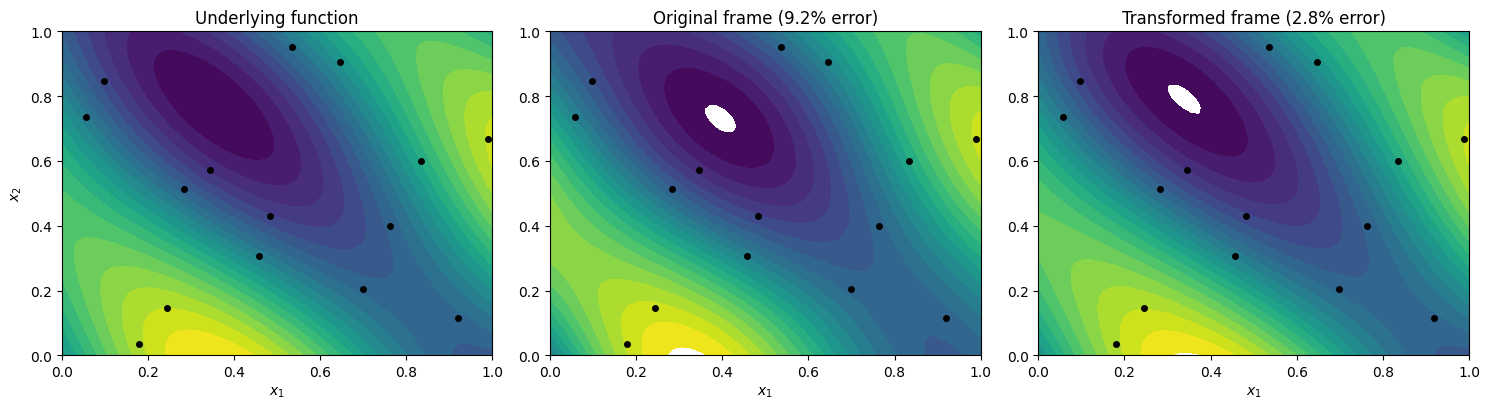

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
levels = np.linspace(truth.min(), truth.max(), 21)

for ax, (field, title) in zip(
    axes,
    [
        (truth, "Underlying function"),
        (baseline, f"Original frame ({baseline_error:.1%} error)"),
        (transformed, f"Transformed frame ({transformed_error:.1%} error)"),
    ],
    strict=True,
):
    ax.contourf(gx, gy, field.reshape(gx.shape), levels=levels)
    ax.plot(X[:, 0], X[:, 1], "k.", markersize=8)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")

axes[0].set_ylabel("$x_2$")
fig.tight_layout()

## Comparing the estimation methods

- **`ge-lhm`** — local Hessians from gradients; `n + 1` points per estimate.
- **`ge-dlhm`** — the same, diagonal only: scaling without rotation, which is what conventional cross-validated scaling amounts to.
- **`fv-lhm`** — local quadratic fits to function values; `n(n+1)/2 + n + 1` points per estimate.
- **`asm`** — active subspace: one global measure instead of many local ones.
- **`ideal`** — a frame you supply. Here we know the answer.

In [6]:
results = {"no transformation": baseline_error}

for method in ("ge-lhm", "ge-dlhm", "fv-lhm", "asm"):
    candidate = IsotropicTransformer(method=method).fit(X, y=y, dy=dy)
    results[method] = fit_and_score(candidate)[1]

# The ideal frame uses the exact rotation the problem was built with. The scaling
# still has to come from somewhere, so we estimate curvature in the decomposable
# frame and take its diagonal -- in axis order, not sorted, so that each scaler
# stays paired with the axis it belongs to.
decomposable = IsotropicTransformer(method="ge-lhm").fit(X @ rotation, dy=dy @ rotation)
ideal = IsotropicTransformer(
    method="ideal", rotation=rotation, scaling=np.sqrt(np.diag(decomposable.curvature_))
).fit(X)
results["ideal"] = fit_and_score(ideal)[1]

for name, error in sorted(results.items(), key=lambda item: item[1]):
    print(f"{name:>20s}: {error:.2%}")

               ideal: 2.39%
              fv-lhm: 2.46%
              ge-lhm: 2.83%
                 asm: 4.63%
             ge-dlhm: 9.01%
   no transformation: 9.18%


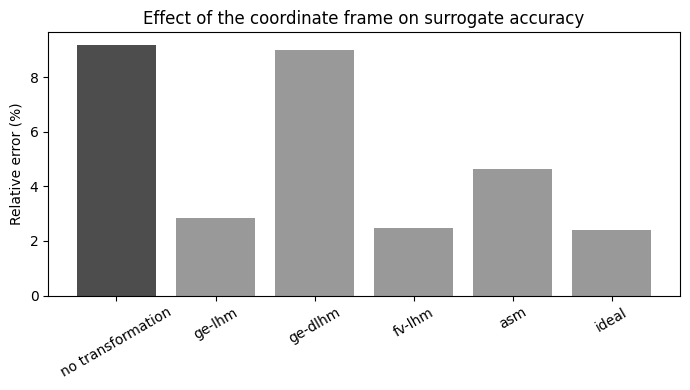

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(results)
ax.bar(names, [results[n] * 100 for n in names], color="0.6")
ax.bar(["no transformation"], [results["no transformation"] * 100], color="0.3")
ax.set_ylabel("Relative error (%)")
ax.set_title("Effect of the coordinate frame on surrogate accuracy")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

The paper's argument in miniature. `ideal` wins, with the two full-rotation methods (`fv-lhm`, `ge-lhm`) close behind on 15 samples.

`ge-dlhm` is the instructive one — `ge-lhm` with the rotation discarded — and it barely beats doing nothing. When the anisotropy is not axis-aligned, scaling the axes cannot reach it. `asm` sits between the two: it finds a rotation, but from one global average.

## Higher dimensions: what is a fair sample budget?

Does the transformation still pay as the problem grows? Answering that needs a rule for how many samples each dimension gets.

The tempting rule is a fixed count *per dimension*. It is not a fair one: RBF accuracy tracks the **fill distance** $h \sim n^{-1/d}$, and the $d$-th root is brutal. Scaling with $d^2$ is the natural correction, since curvature has $d(d+1)/2$ parameters. Compute what both rules give:

In [8]:
def fill_distance(n_samples, n_features):
    """Typical spacing between neighbouring samples in the unit cube."""
    return n_samples ** (-1 / n_features)


def budget_table(title, multipliers, budget):
    """Print sample count and fill distance for each dimension and multiplier."""
    print(title.center(57))
    print(f"{'d':>3}" + "".join(f"{f'c={c}':^18}" for c in multipliers))
    for d in (2, 4, 8, 16):
        cells = ""
        for c in multipliers:
            n = budget(c, d)
            cells += f"{f'n={n}  h={fill_distance(n, d):.3f}':^18}"
        print(f"{d:>3}" + cells)


budget_table("linear rule,  n = c*d", (5, 10, 20), lambda c, d: c * d)
print()
budget_table("quadratic rule,  n = c*d(d+1)/2", (1, 2, 4), lambda c, d: c * d * (d + 1) // 2)

print()
print("samples needed to match the spacing of 20 samples in 2-D:")
target = fill_distance(20, 2)
for d in (2, 4, 8, 16):
    print(f"  {d:>2}-D: n = {target**-d:>18,.0f}")

                  linear rule,  n = c*d                  
  d       c=5               c=10              c=20       
  2  n=10  h=0.316     n=20  h=0.224     n=40  h=0.158   
  4  n=20  h=0.473     n=40  h=0.398     n=80  h=0.334   
  8  n=40  h=0.631     n=80  h=0.578     n=160  h=0.530  
 16  n=80  h=0.760     n=160  h=0.728    n=320  h=0.697  

             quadratic rule,  n = c*d(d+1)/2             
  d       c=1               c=2               c=4        
  2   n=3  h=0.577      n=6  h=0.408     n=12  h=0.289   
  4  n=10  h=0.562     n=20  h=0.473     n=40  h=0.398   
  8  n=36  h=0.639     n=72  h=0.586     n=144  h=0.537  
 16  n=136  h=0.736    n=272  h=0.704    n=544  h=0.675  

samples needed to match the spacing of 20 samples in 2-D:
   2-D: n =                 20
   4-D: n =                400
   8-D: n =            160,000
  16-D: n =     25,600,000,000


**Neither rule is fair, and the quadratic one barely helps.** At 16-D, moving from $n = 5d$ to $n = d(d+1)/2$ raises the count 70% and tightens the spacing 3%; matching a modest 2-D density would take $2.6 \times 10^{10}$ points. The curse is exponential, so every polynomial budget is asymptotically the same budget.

So **absolute errors are not comparable across dimensions under any affordable budget.** The valid comparison is within a dimension — the ratio between frames at matched sample count, which is what the paper compares.

The budget still matters, for a different reason: the frame is a symmetric matrix with $d(d+1)/2$ parameters estimated from the same samples, so budgeting per curvature parameter holds *that* subproblem equally determined. Hence $n = c \cdot d(d+1)/2$ below — with no pretence it defeats the curse.

In [9]:
DIMENSIONS = (2, 4, 8, 16)
PER_PARAMETER = (2, 4, 8)
REPEATS = 3
EPSILONS = np.logspace(-2, 1, 15)
MAX_SAMPLES = 600  # past this a cell costs minutes; see the skipped entry below


def trial(n_features, n_samples, seed):
    """Fit a GE-RBF in both frames on one random problem. Returns the two errors."""
    coupling = random_rotation(n_features, rng=seed)
    draw = qmc.LatinHypercube(d=n_features, seed=seed).random(n_samples)
    drawn_y, drawn_dy = non_isotropic(draw, coupling)

    # A large independent test set: this is the number we actually care about.
    test = qmc.LatinHypercube(d=n_features, seed=seed + 1000).random(2000)
    test_truth, _ = non_isotropic(test, coupling)

    def error(transformer=None):
        if transformer is None:
            fit_X, fit_dy, test_X = draw, drawn_dy, test
        else:
            fit_X = transformer.transform(draw)
            fit_dy = transformer.transform_gradient(drawn_dy)
            test_X = transformer.transform(test)

        found = gradient_search(
            RBFRegressor(), fit_X, drawn_y, fit_dy, epsilons=EPSILONS, max_condition=1e13
        )
        prediction = found.best_estimator.predict(test_X)
        return np.linalg.norm(prediction - test_truth) / np.linalg.norm(test_truth)

    return error(), error(IsotropicTransformer(method="ge-lhm").fit(draw, dy=drawn_dy))


study = {}
for n_features in DIMENSIONS:
    n_parameters = n_features * (n_features + 1) // 2
    for per_parameter in PER_PARAMETER:
        n_samples = per_parameter * n_parameters
        if n_samples > MAX_SAMPLES:
            print(
                f"{n_features:2d}-D, {per_parameter} per parameter: n={n_samples} exceeds the budget, skipped"
            )
            continue

        pairs = [
            trial(n_features, n_samples, seed=100 * n_features + 10 * per_parameter + r)
            for r in range(REPEATS)
        ]
        plain, framed = np.median(pairs, axis=0)
        study[n_features, per_parameter] = (plain, framed)
        print(
            f"{n_features:2d}-D, {per_parameter} per parameter (n={n_samples:4d}, h={fill_distance(n_samples, n_features):.2f}): "
            f"original {plain:6.1%}   transformed {framed:6.1%}   improvement {plain / framed:4.2f}x"
        )

 2-D, 2 per parameter (n=   6, h=0.41): original 117.7%   transformed  64.2%   improvement 1.83x
 2-D, 4 per parameter (n=  12, h=0.29): original  16.6%   transformed  11.0%   improvement 1.51x
 2-D, 8 per parameter (n=  24, h=0.20): original   1.9%   transformed   0.5%   improvement 3.48x
 4-D, 2 per parameter (n=  20, h=0.47): original  62.6%   transformed  28.4%   improvement 2.21x


 4-D, 4 per parameter (n=  40, h=0.40): original  34.0%   transformed  14.8%   improvement 2.29x


 4-D, 8 per parameter (n=  80, h=0.33): original  18.6%   transformed   4.2%   improvement 4.42x


 8-D, 2 per parameter (n=  72, h=0.59): original  69.0%   transformed  37.5%   improvement 1.84x


 8-D, 4 per parameter (n= 144, h=0.54): original  44.3%   transformed  24.4%   improvement 1.81x


 8-D, 8 per parameter (n= 288, h=0.49): original  39.5%   transformed  15.2%   improvement 2.60x


16-D, 2 per parameter (n= 272, h=0.70): original  70.6%   transformed  45.9%   improvement 1.54x


16-D, 4 per parameter (n= 544, h=0.67): original  61.8%   transformed  38.5%   improvement 1.61x
16-D, 8 per parameter: n=1088 exceeds the budget, skipped


The skipped cell is the curse showing up in the compute budget rather than the error: at 16-D the quadratic rule wants 1088 samples, making the stacked gradient-enhanced system 18 496 by 1088.

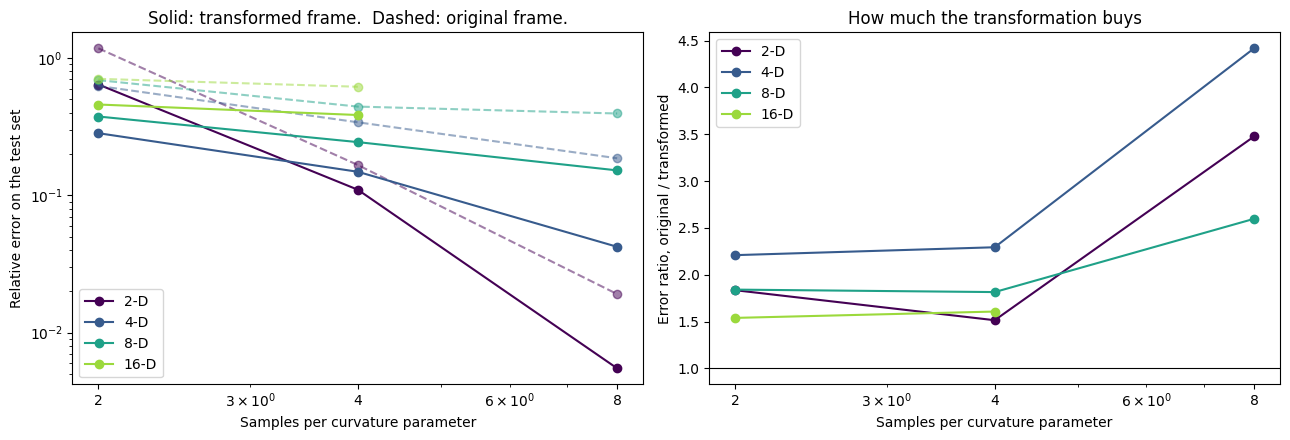

In [10]:
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
colours = plt.cm.viridis(np.linspace(0, 0.85, len(DIMENSIONS)))

for colour, n_features in zip(colours, DIMENSIONS, strict=True):
    budgets = [c for c in PER_PARAMETER if (n_features, c) in study]
    plain = [study[n_features, c][0] for c in budgets]
    framed = [study[n_features, c][1] for c in budgets]

    left.plot(budgets, plain, "o--", color=colour, alpha=0.5)
    left.plot(budgets, framed, "o-", color=colour, label=f"{n_features}-D")
    right.plot(
        budgets,
        [p / f for p, f in zip(plain, framed, strict=True)],
        "o-",
        color=colour,
        label=f"{n_features}-D",
    )

for ax in (left, right):
    ax.set_xscale("log")
    ax.set_xticks(PER_PARAMETER, [str(c) for c in PER_PARAMETER])
    ax.set_xlabel("Samples per curvature parameter")
    ax.legend()

left.set_yscale("log")
left.set_ylabel("Relative error on the test set")
left.set_title("Solid: transformed frame.  Dashed: original frame.")

right.axhline(1.0, color="k", lw=0.8)
right.set_ylabel("Error ratio, original / transformed")
right.set_title("How much the transformation buys")

fig.tight_layout()

**The transformation wins everywhere** — every ratio above 1, at every dimension and budget, densest budget best in all four. That is a within-dimension comparison, so the budget argument does not touch it.

**The budget does what it was chosen for, and only that.** Down any column the *ratio* holds a narrow band, roughly 1.5x to 4x, while the *absolute* error climbs from under a percent in 2-D to tens of percent in 16-D. Reading the left panel as "the method degrades with dimension" would be reading the curse, not the method.

**The rule under-samples low dimensions**: two per parameter in 2-D is six points, useless in either frame.

**16-D stays hard.** At 544 evaluations *with* gradients the surrogate is still tens of percent out. The transformation is not a substitute for samples — it is a fixed pre-processing step growing linearly with dimension, while the sample requirement grows exponentially.

## Where do the gradients actually pay?

Gradients have done three jobs here: estimate the frame, score shape parameters, and fill extra rows in the fitting system. Which one earns the benefit?

To separate them, fit a **function-value model** — no gradient rows at all — while still using gradients for the frame and the search. `use_gradients_in_fit=False` does this, which also makes them a genuinely independent scoring signal: nothing held out, no extra evaluations.

Both models keep one centre per sample, so flexibility is fixed and only the fitting information differs. GE numbers are reused from the previous section on the same seeds, so every comparison is paired.

In [11]:
def fv_trial(n_features, n_samples, seed):
    """Same problem and design as the previous section, fitted to function values only."""
    coupling = random_rotation(n_features, rng=seed)
    draw = qmc.LatinHypercube(d=n_features, seed=seed).random(n_samples)
    drawn_y, drawn_dy = non_isotropic(draw, coupling)

    test = qmc.LatinHypercube(d=n_features, seed=seed + 1000).random(2000)
    test_truth, _ = non_isotropic(test, coupling)

    def error(transformer=None):
        if transformer is None:
            fit_X, fit_dy, test_X = draw, drawn_dy, test
        else:
            fit_X = transformer.transform(draw)
            fit_dy = transformer.transform_gradient(drawn_dy)
            test_X = transformer.transform(test)

        found = gradient_search(
            RBFRegressor(),
            fit_X,
            drawn_y,
            fit_dy,
            use_gradients_in_fit=False,  # gradients score the fit, they do not enter it
            epsilons=EPSILONS,
            max_condition=1e13,
        )
        prediction = found.best_estimator.predict(test_X)
        return np.linalg.norm(prediction - test_truth) / np.linalg.norm(test_truth)

    return error(), error(IsotropicTransformer(method="ge-lhm").fit(draw, dy=drawn_dy))


print(f"{'':>16} {'FV orig':>9} {'FV tran':>9} {'GE orig':>9} {'GE tran':>9}")
print("-" * 56)

comparison = {}
for (n_features, per_parameter), (ge_plain, ge_framed) in study.items():
    n_samples = per_parameter * n_features * (n_features + 1) // 2
    # Same seeds as the previous section, so the two models see identical designs.
    fv_plain, fv_framed = np.median(
        [
            fv_trial(n_features, n_samples, seed=100 * n_features + 10 * per_parameter + r)
            for r in range(REPEATS)
        ],
        axis=0,
    )
    comparison[n_features, per_parameter] = (fv_plain, fv_framed, ge_plain, ge_framed)
    print(
        f"{f'{n_features:2d}-D n={n_samples:<4d}':>16} {fv_plain:>8.1%} {fv_framed:>8.1%} {ge_plain:>8.1%} {ge_framed:>8.1%}"
    )

                   FV orig   FV tran   GE orig   GE tran
--------------------------------------------------------
      2-D n=6       86.0%    68.5%   117.7%    64.2%
      2-D n=12      18.9%    12.4%    16.6%    11.0%
      2-D n=24       2.5%     1.3%     1.9%     0.5%
      4-D n=20      54.6%    23.0%    62.6%    28.4%
      4-D n=40      37.4%    15.9%    34.0%    14.8%


      4-D n=80      20.9%     6.1%    18.6%     4.2%
      8-D n=72      69.5%    47.4%    69.0%    37.5%


      8-D n=144     49.2%    25.6%    44.3%    24.4%


      8-D n=288     47.2%    16.9%    39.5%    15.2%


     16-D n=272     71.6%    50.6%    70.6%    45.9%


     16-D n=544     67.7%    43.8%    61.8%    38.5%


In [12]:
rows = np.array(list(comparison.values()))
fv_plain, fv_framed, ge_plain, ge_framed = rows.T

# Gradients used as pre-processing: what transforming the frame buys.
preprocessing_fv = fv_plain / fv_framed
preprocessing_ge = ge_plain / ge_framed
# Gradients used as fitting data: what adding gradient rows to the system buys.
in_fit_plain = fv_plain / ge_plain
in_fit_framed = fv_framed / ge_framed

print("Gradients spent on PRE-PROCESSING (frame transform)")
print(f"  function-value models:    median {np.median(preprocessing_fv):.2f}x")
print(f"  gradient-enhanced models: median {np.median(preprocessing_ge):.2f}x")
print()
print("Gradients spent on FITTING (extra rows in the system)")
print(
    f"  in the original frame:    median {np.median(in_fit_plain):.2f}x"
    f"   ({np.sum(in_fit_plain < 1)}/{len(in_fit_plain)} configurations made WORSE)"
)
print(
    f"  in the transformed frame: median {np.median(in_fit_framed):.2f}x"
    f"   ({np.sum(in_fit_framed < 1)}/{len(in_fit_framed)} configurations made WORSE)"
)

Gradients spent on PRE-PROCESSING (frame transform)
  function-value models:    median 1.88x
  gradient-enhanced models: median 1.84x

Gradients spent on FITTING (extra rows in the system)
  in the original frame:    median 1.10x   (2/11 configurations made WORSE)
  in the transformed frame: median 1.11x   (1/11 configurations made WORSE)


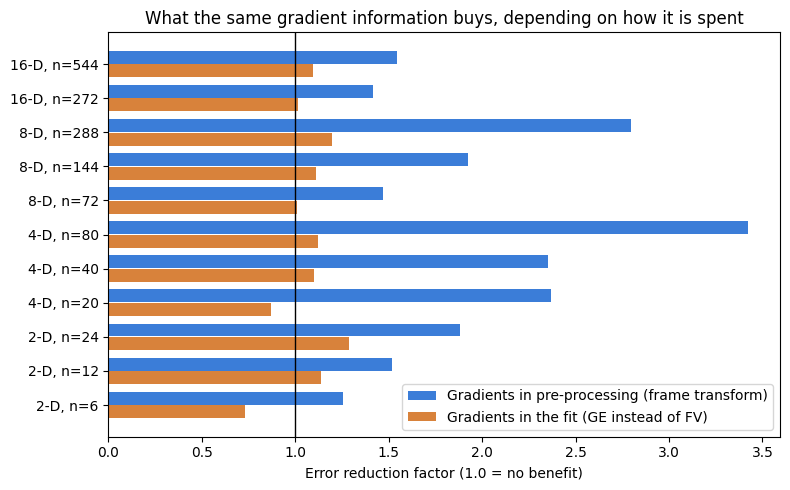

In [13]:
labels = [f"{d}-D, n={c * d * (d + 1) // 2}" for d, c in comparison]
position = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    position + 0.2,
    preprocessing_fv,
    height=0.38,
    color="#3b7dd8",
    label="Gradients in pre-processing (frame transform)",
)
ax.barh(
    position - 0.2,
    in_fit_plain,
    height=0.38,
    color="#d8823b",
    label="Gradients in the fit (GE instead of FV)",
)

ax.axvline(1.0, color="k", lw=1)
ax.set_yticks(position, labels)
ax.set_xlabel("Error reduction factor (1.0 = no benefit)")
ax.set_title("What the same gradient information buys, depending on how it is spent")
ax.legend(loc="lower right")
fig.tight_layout()

**The same gradients are worth far more as pre-processing than as fitting data.**

On the coordinate frame they cut the error by about a factor of two, everywhere. As extra rows in the fitting system they buy about ten percent, and in a couple of configurations make the model *worse*.

This is the paper's central claim in one figure: the dominant error is the mismatch between an isotropic basis and an anisotropic response, not a shortage of information. Pour more information into a model with the wrong functional form and most of it is spent fighting the form.

It also reframes what gradients are *for*. The frame and the shape-parameter search are cheap, need no extra evaluations, and account for nearly all the benefit. Filling the fitting system is the expensive use — it makes the system `(1 + d)` times taller — and contributes least.

Two caveats. Three repeats is not many, so the medians across configurations are the trustworthy numbers; a 9-repeat check at 4-D and 8-D agrees. And the hint that gradients pay better *inside* the transformed frame is visible in these medians but small against the run-to-run spread.

## A caveat

The test problem is decomposable, so an ideal frame exists to be found. Where the Hessian varies strongly across the domain there may be no single global frame worth finding, and the transformation will offer little. Section 7 of the paper covers this.